# Modélisation du Taux NEET par Commune
**Analyse prédictive basée sur 31 indicateurs socio-démographiques | 552 communes**

Ce notebook reproduit l'ensemble de la chaîne d'analyse :
1. Chargement & exploration des données
2. Analyse exploratoire (EDA)
3. Corrélations avec le taux NEET
4. Modélisation (Régression Linéaire, Elastic Net, Random Forest, Gradient Boosting)
5. Évaluation & comparaison des modèles
6. Analyse des coefficients & interprétation
7. Analyse SHAP (importance des variables)
8. Prédictions & classement des communes
9. Export Excel des résultats

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installé. Installez-le avec : pip install shap")

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage
import io
import os

# Style matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COULEUR_PRINCIPALE = '#1a5276'
COULEUR_ACCENT     = '#e74c3c'
COULEUR_VERT       = '#1e8449'

print("✅ Imports réussis")

✅ Imports réussis


## 1. Chargement des données

In [2]:
# ─── Adaptez ce chemin si nécessaire ───
FICHIER_EXCEL = 'Modele_NEET_Communes.xlsx'

df = pd.read_excel(FICHIER_EXCEL, sheet_name='Données')

print(f"Données chargées : {df.shape[0]} communes × {df.shape[1]} variables")
df.head(3)

Données chargées : 552 communes × 33 variables


,Commune_Nom,D1_Taux_Feminite_15_35,D4_Mariage_Precoce,D5_Taux_Orphelins,D6_Taux_Urbanisation,S1_Taux_Descolarisation,S2_Taux_NonScolarisation,S3_Taux_Achevement_BFEM,S4_Taux_Analphabetisme,S5_Taux_Formation_Pro,...,H1_Location_Precaire,H2_Acces_Eau_Potable,H3_Acces_Toilettes_Adequates,H4_Surpeuplement,H5_Indice_Equipement_Moyen,M1_Migration_Recente_1an,M3_Emig_Pour_Travail,M4_Emig_Pour_Etudes,R1_Taille_Moyenne_Menages,R3_Fecondite_Precoce
0,GOREE,0.454545,0.000000,0.090909,1.0,0.636364,0.272727,0.424242,0.151515,0.303030,...,0.200000,0.0,1.000000,0.133333,7.800000,0.030303,1.000000,0.000000,5.800000,0.000000
1,DAKAR-PLATEAU,0.241304,0.158639,0.083798,1.0,0.525775,0.134844,0.168023,0.536266,0.097051,...,0.176090,0.0,0.945073,0.172859,7.550889,0.649418,0.327273,0.545455,4.066236,0.144218
2,MEDINA,0.480820,0.184390,0.153786,1.0,0.511225,0.232049,0.372436,0.281954,0.192765,...,0.240824,0.0,0.953638,0.224726,4.837733,0.180214,0.613333,0.200000,4.557630,0.147749


In [3]:
# Variable cible et features
TARGET   = 'E1_Taux_NEET'
ID_COL   = 'Commune_Nom'
FEATURES = [c for c in df.columns if c not in [TARGET, ID_COL]]

print(f"Variable cible  : {TARGET}")
print(f"Nombre de features : {len(FEATURES)}")
print(f"\nValeurs manquantes :")
print(df[FEATURES + [TARGET]].isnull().sum()[lambda s: s > 0])

# Supprimer les lignes avec NaN si nécessaire
df_clean = df.dropna(subset=FEATURES + [TARGET]).copy()
print(f"\nCommunes après nettoyage : {len(df_clean)}")

Variable cible  : E1_Taux_NEET
Nombre de features : 31

Valeurs manquantes :
M3_Emig_Pour_Travail    19
M4_Emig_Pour_Etudes     19
dtype: int64

Communes après nettoyage : 533


## 2. Analyse Exploratoire (EDA)

In [4]:
# Statistiques descriptives du taux NEET
desc = df_clean[TARGET].describe()
print("Statistiques du Taux NEET :")
print(desc.round(4))

Statistiques du Taux NEET :
count    533.0000
mean       0.4570
std        0.1296
min        0.0748
25%        0.3489
50%        0.4660
75%        0.5442
max        0.7895
Name: E1_Taux_NEET, dtype: float64


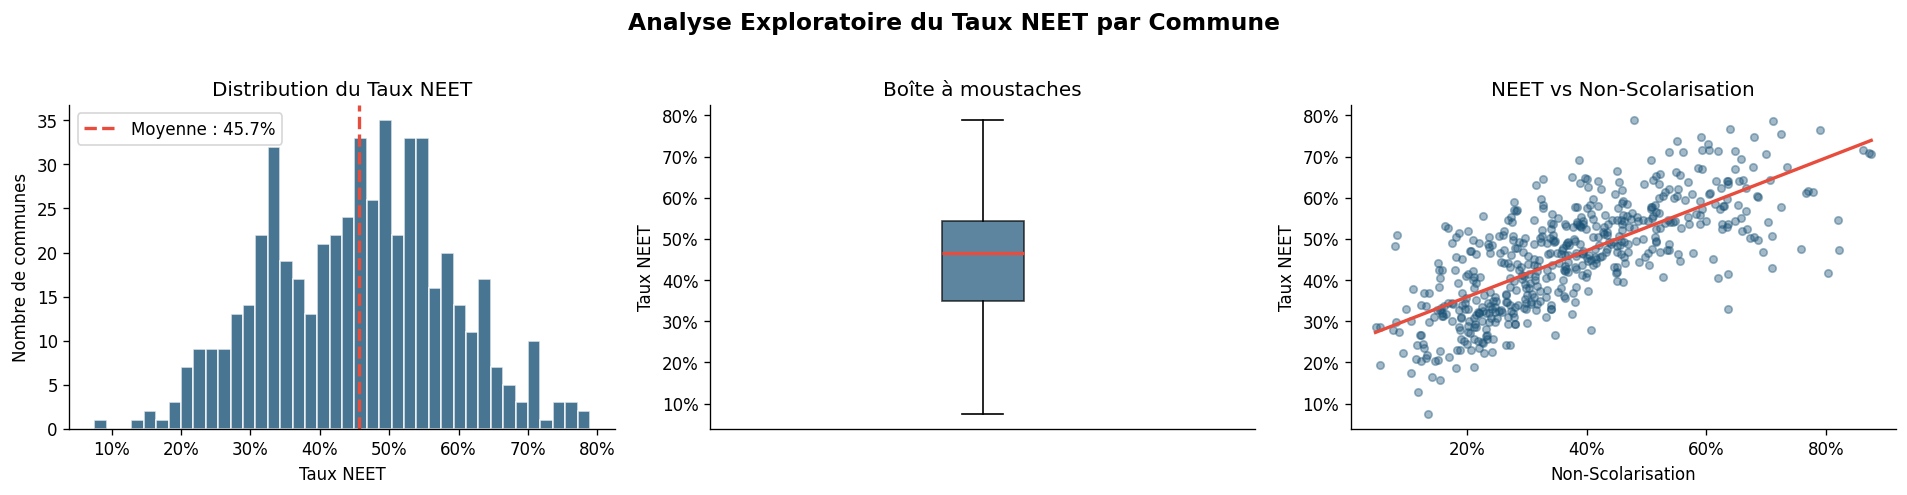

✅ Figure EDA sauvegardée


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Analyse Exploratoire du Taux NEET par Commune', fontsize=14, fontweight='bold', y=1.02)

# Distribution
axes[0].hist(df_clean[TARGET], bins=40, color=COULEUR_PRINCIPALE, alpha=0.8, edgecolor='white')
axes[0].axvline(df_clean[TARGET].mean(), color=COULEUR_ACCENT, linestyle='--', linewidth=2, label=f'Moyenne : {df_clean[TARGET].mean():.1%}')
axes[0].set_xlabel('Taux NEET')
axes[0].set_ylabel('Nombre de communes')
axes[0].set_title('Distribution du Taux NEET')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean[TARGET], patch_artist=True,
                boxprops=dict(facecolor=COULEUR_PRINCIPALE, alpha=0.7),
                medianprops=dict(color=COULEUR_ACCENT, linewidth=2))
axes[1].set_ylabel('Taux NEET')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title('Boîte à moustaches')
axes[1].set_xticks([])

# NEET vs Non-Scolarisation
axes[2].scatter(df_clean['S2_Taux_NonScolarisation'], df_clean[TARGET],
                alpha=0.4, color=COULEUR_PRINCIPALE, s=20)
m, b = np.polyfit(df_clean['S2_Taux_NonScolarisation'], df_clean[TARGET], 1)
x_line = np.linspace(df_clean['S2_Taux_NonScolarisation'].min(),
                     df_clean['S2_Taux_NonScolarisation'].max(), 100)
axes[2].plot(x_line, m*x_line + b, color=COULEUR_ACCENT, linewidth=2)
axes[2].set_xlabel('Non-Scolarisation')
axes[2].set_ylabel('Taux NEET')
axes[2].set_title('NEET vs Non-Scolarisation')
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('eda_neet.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure EDA sauvegardée")

In [6]:
# Statistiques descriptives de toutes les variables
stats = df_clean[FEATURES + [TARGET]].describe().T.round(4)
stats.index.name = 'Variable'
stats

,count,mean,std,min,25%,50%,75%,max
Variable,,,,,,,,
D1_Taux_Feminite_15_35,533.0,0.4989,0.0398,0.2413,0.4800,0.5021,0.5228,0.5957
D4_Mariage_Precoce,533.0,0.3750,0.1546,0.0000,0.2392,0.3628,0.5088,0.7794
D5_Taux_Orphelins,533.0,0.1803,0.0516,0.0467,0.1482,0.1743,0.2037,0.3907
D6_Taux_Urbanisation,533.0,0.3581,0.4578,0.0000,0.0000,0.0000,1.0000,1.0000
S1_Taux_Descolarisation,533.0,0.4065,0.1206,0.0855,0.3194,0.4033,0.5055,0.7023
S2_Taux_NonScolarisation,533.0,0.3743,0.1683,0.0470,0.2409,0.3571,0.4852,0.8761
S3_Taux_Achevement_BFEM,533.0,0.1536,0.1162,0.0000,0.0612,0.1186,0.2300,0.6196
S4_Taux_Analphabetisme,533.0,0.3782,0.1220,0.0922,0.2846,0.3630,0.4617,0.8182
S5_Taux_Formation_Pro,533.0,0.0728,0.0648,0.0000,0.0280,0.0522,0.1017,0.4598


## 3. Corrélations avec le Taux NEET

In [7]:
corr = df_clean[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

def classer_force(r):
    r = abs(r)
    if r >= 0.5: return 'Forte'
    if r >= 0.3: return 'Modérée'
    return 'Faible'

df_corr = pd.DataFrame({
    'Corrélation': corr,
    'Direction': corr.apply(lambda x: 'Positive' if x >= 0 else 'Négative'),
    'Force': corr.apply(classer_force)
}).reset_index().rename(columns={'index': 'Variable'})

print("Top 10 corrélations (positives) :")
print(df_corr.sort_values('Corrélation', ascending=False).head(10).to_string(index=False))
print("\nTop 10 corrélations (négatives) :")
print(df_corr.sort_values('Corrélation').head(10).to_string(index=False))

Top 10 corrélations (positives) :
                       Variable  Corrélation Direction   Force
             D4_Mariage_Precoce     0.752457  Positive   Forte
       S2_Taux_NonScolarisation     0.730466  Positive   Forte
           R3_Fecondite_Precoce     0.704597  Positive   Forte
                E2_Taux_Chomage     0.667674  Positive   Forte
        E4_Part_Emploi_Agricole     0.646828  Positive   Forte
      R1_Taille_Moyenne_Menages     0.557937  Positive   Forte
         S4_Taux_Analphabetisme     0.525259  Positive   Forte
E5_Pauvrete_Alim_Conjoncturelle     0.494507  Positive Modérée
         E8_Inactivite_Feminine     0.481254  Positive Modérée
  E6_Pauvrete_Alim_Structurelle     0.460496  Positive Modérée

Top 10 corrélations (négatives) :
                    Variable  Corrélation Direction   Force
     S3_Taux_Achevement_BFEM    -0.765542  Négative   Forte
  H5_Indice_Equipement_Moyen    -0.723484  Négative   Forte
       S5_Taux_Formation_Pro    -0.718350  Négative   Fort

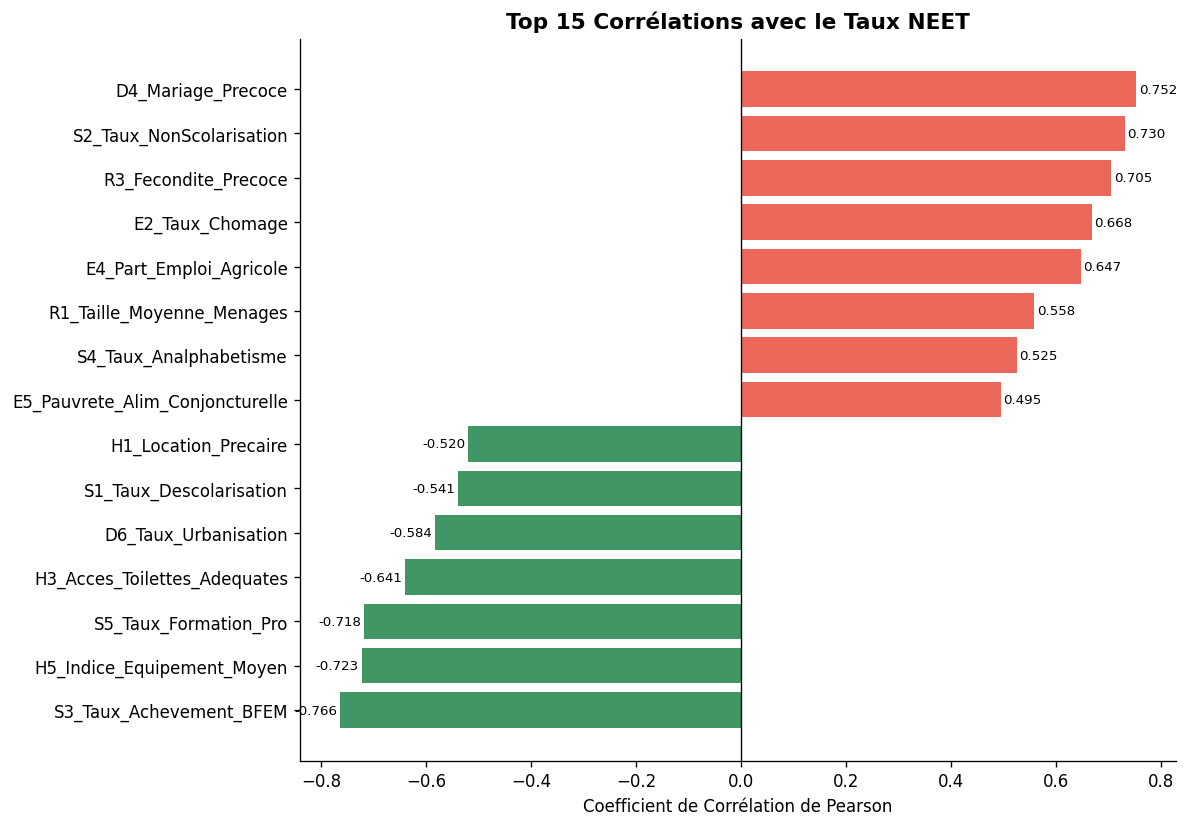

In [8]:
# Visualisation des 15 plus fortes corrélations
top_pos = df_corr.nlargest(8, 'Corrélation')
top_neg = df_corr.nsmallest(7, 'Corrélation')
top_all = pd.concat([top_neg, top_pos]).sort_values('Corrélation')

fig, ax = plt.subplots(figsize=(10, 7))
colors = [COULEUR_ACCENT if v >= 0 else COULEUR_VERT for v in top_all['Corrélation']]
bars = ax.barh(top_all['Variable'], top_all['Corrélation'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient de Corrélation de Pearson')
ax.set_title('Top 15 Corrélations avec le Taux NEET', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_all['Corrélation']):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('correlations_neet.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modélisation

In [9]:
X = df_clean[FEATURES].values
y = df_clean[TARGET].values
communes = df_clean[ID_COL].values

# Split 80/20 stratifié par quartile NEET
quartiles = pd.qcut(y, 4, labels=False)
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    X, y, communes, test_size=0.2, random_state=42, stratify=quartiles
)
print(f"Train : {len(X_train)} communes | Test : {len(X_test)} communes")

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train : 426 communes | Test : 107 communes


In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

modeles = {
    'Régression Linéaire': LinearRegression(),
    'Elastic Net'        : ElasticNetCV(cv=5, random_state=42, max_iter=5000),
    'Random Forest'      : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=200, random_state=42),
}

resultats = {}
predictions_test = {}

for nom, modele in modeles.items():
    # Choisir données normalisées ou brutes
    if nom in ['Régression Linéaire', 'Elastic Net']:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    modele.fit(Xtr, y_train)
    y_pred = modele.predict(Xte)
    predictions_test[nom] = y_pred

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv_r2 = cross_val_score(modele, Xtr, y_train, cv=cv, scoring='r2').mean()

    resultats[nom] = {'R² Test': r2, 'RMSE': rmse, 'MAE': mae, 'CV R² (5-fold)': cv_r2}
    print(f"[{nom}]  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  CV-R²={cv_r2:.4f}")

df_resultats = pd.DataFrame(resultats).T.round(4)
print("\n", df_resultats)

[Régression Linéaire]  R²=0.9296  RMSE=0.0325  MAE=0.0249  CV-R²=0.9383


[Elastic Net]  R²=0.9312  RMSE=0.0321  MAE=0.0247  CV-R²=0.9416


[Random Forest]  R²=0.7939  RMSE=0.0556  MAE=0.0431  CV-R²=0.8688


[Gradient Boosting]  R²=0.8711  RMSE=0.0440  MAE=0.0344  CV-R²=0.9182

                      R² Test    RMSE     MAE  CV R² (5-fold)
Régression Linéaire   0.9296  0.0325  0.0249          0.9383
Elastic Net           0.9312  0.0321  0.0247          0.9416
Random Forest         0.7939  0.0556  0.0431          0.8688
Gradient Boosting     0.8711  0.0440  0.0344          0.9182


In [11]:
# Modèle retenu : Régression Linéaire
MODELE_RETENU = 'Régression Linéaire'
modele_final  = modeles[MODELE_RETENU]
y_pred_final  = predictions_test[MODELE_RETENU]
print(f"✅ Modèle retenu : {MODELE_RETENU}  |  R²={resultats[MODELE_RETENU]['R² Test']:.4f}")

✅ Modèle retenu : Régression Linéaire  |  R²=0.9296


## 5. Évaluation & Visualisation des résultats

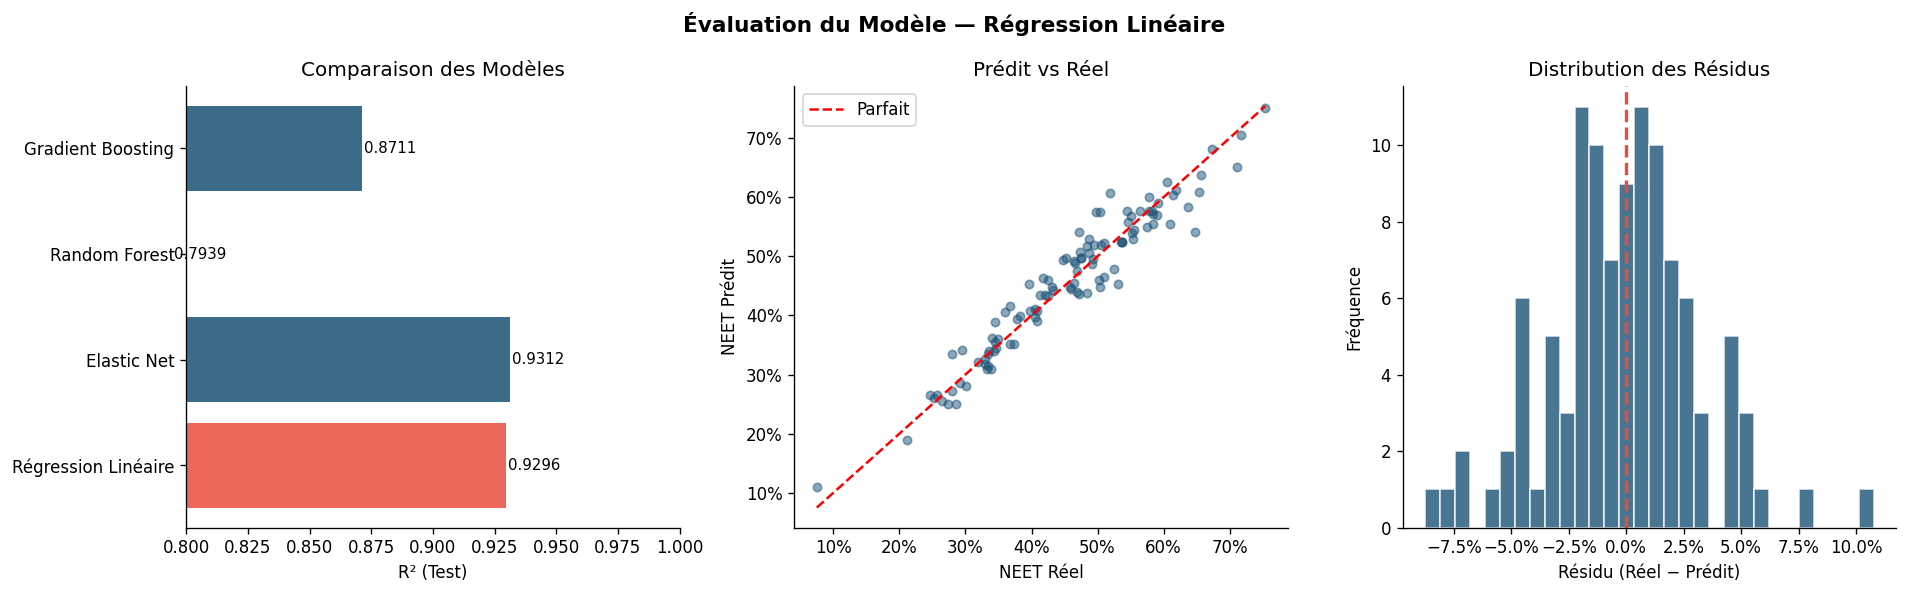

✅ Figure résultats sauvegardée


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Évaluation du Modèle — {MODELE_RETENU}', fontsize=13, fontweight='bold')

# 1. Comparaison des R² modèles
noms = list(df_resultats.index)
r2s  = df_resultats['R² Test'].values
cols = [COULEUR_ACCENT if n == MODELE_RETENU else COULEUR_PRINCIPALE for n in noms]
bars = axes[0].barh(noms, r2s, color=cols, alpha=0.85)
axes[0].set_xlim(0.8, 1.0)
axes[0].set_xlabel('R² (Test)')
axes[0].set_title('Comparaison des Modèles')
for bar, val in zip(bars, r2s):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# 2. Prédit vs Réel
axes[1].scatter(y_test, y_pred_final, alpha=0.5, color=COULEUR_PRINCIPALE, s=25)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
axes[1].set_xlabel('NEET Réel')
axes[1].set_ylabel('NEET Prédit')
axes[1].set_title('Prédit vs Réel')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# 3. Distribution des résidus
residus = y_test - y_pred_final
axes[2].hist(residus, bins=30, color=COULEUR_PRINCIPALE, alpha=0.8, edgecolor='white')
axes[2].axvline(0, color=COULEUR_ACCENT, linestyle='--', linewidth=2)
axes[2].set_xlabel('Résidu (Réel − Prédit)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution des Résidus')
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure résultats sauvegardée")

## 6. Analyse des Coefficients

In [13]:
coefs = modele_final.coef_

def classer_impact(c):
    a = abs(c)
    if a >= 0.03: return 'FORT'
    if a >= 0.01: return 'Modéré'
    return 'Faible'

df_coefs = pd.DataFrame({
    'Variable'    : FEATURES,
    'Coefficient' : coefs,
    '|Coefficient|': np.abs(coefs),
    'Direction'   : ['Augmente NEET' if c > 0 else 'Diminue NEET' for c in coefs],
    'Impact'      : [classer_impact(c) for c in coefs],
}).sort_values('|Coefficient|', ascending=False)

print(df_coefs.head(15).to_string(index=False))

                     Variable  Coefficient  |Coefficient|     Direction Impact
     S2_Taux_NonScolarisation     0.077698       0.077698 Augmente NEET   FORT
              E2_Taux_Chomage     0.062936       0.062936 Augmente NEET   FORT
      S1_Taux_Descolarisation     0.036940       0.036940 Augmente NEET   FORT
       E8_Inactivite_Feminine     0.035182       0.035182 Augmente NEET   FORT
        S5_Taux_Formation_Pro    -0.024171       0.024171  Diminue NEET Modéré
           D4_Mariage_Precoce     0.013097       0.013097 Augmente NEET Modéré
       D1_Taux_Feminite_15_35     0.007278       0.007278 Augmente NEET Faible
            D5_Taux_Orphelins     0.007060       0.007060 Augmente NEET Faible
E6_Pauvrete_Alim_Structurelle     0.007040       0.007040 Augmente NEET Faible
         T2_Possession_Mobile    -0.006571       0.006571  Diminue NEET Faible
   H5_Indice_Equipement_Moyen     0.006334       0.006334 Augmente NEET Faible
      E4_Part_Emploi_Agricole     0.006009       0.0

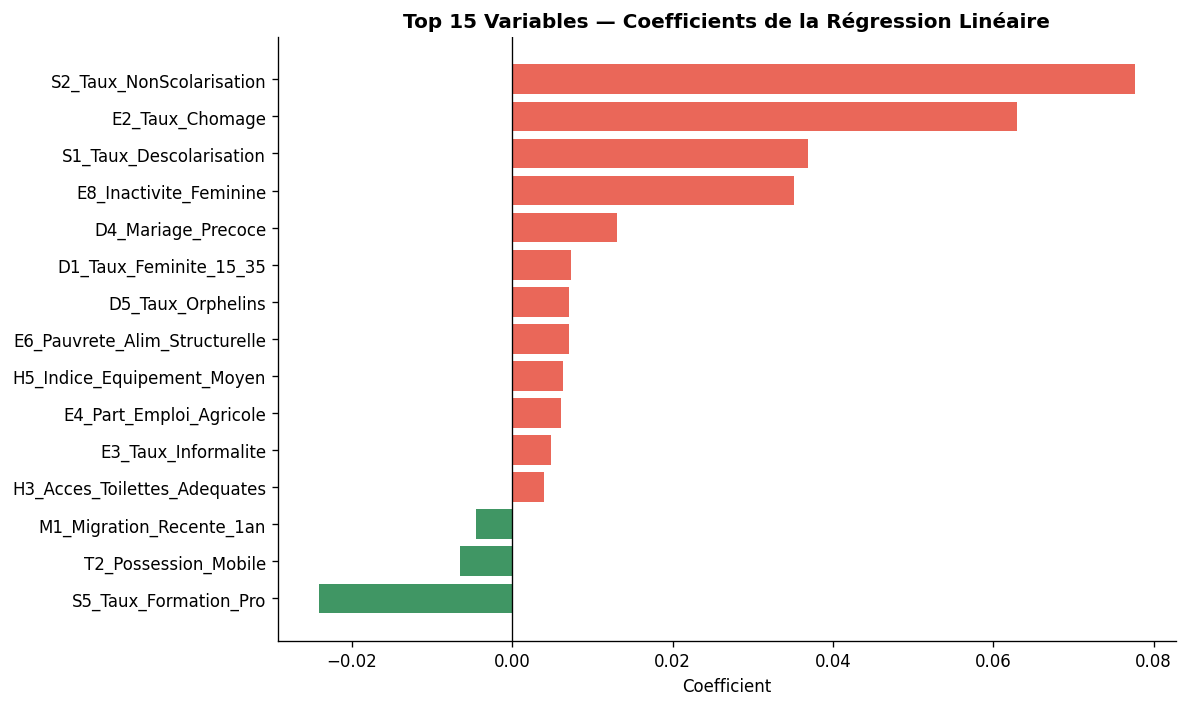

In [14]:
top15 = df_coefs.head(15).sort_values('Coefficient')
fig, ax = plt.subplots(figsize=(10, 6))
cols = [COULEUR_ACCENT if v >= 0 else COULEUR_VERT for v in top15['Coefficient']]
ax.barh(top15['Variable'], top15['Coefficient'], color=cols, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Top 15 Variables — Coefficients de la Régression Linéaire', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('coefficients_neet.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Analyse SHAP

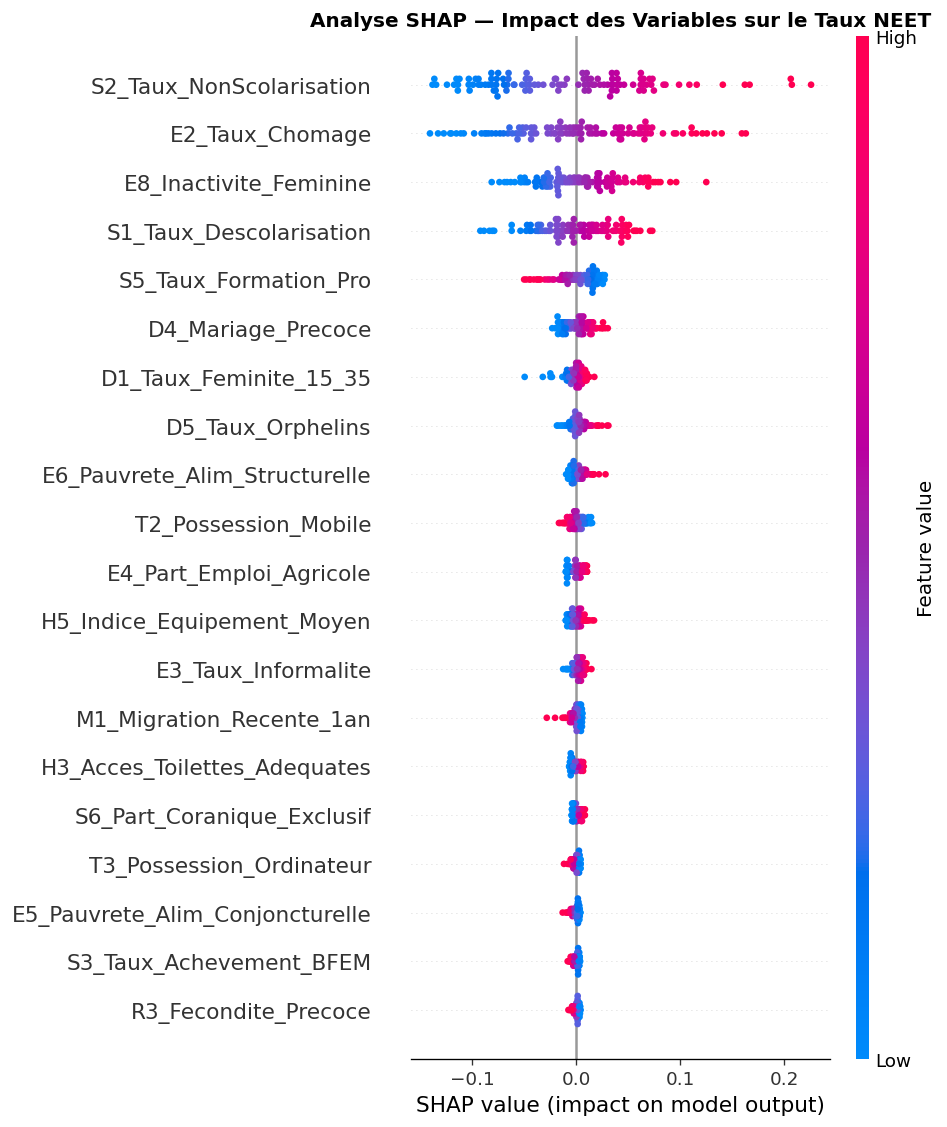

✅ Figure SHAP sauvegardée


In [15]:
if SHAP_AVAILABLE:
    explainer = shap.LinearExplainer(modele_final, X_train_sc)
    shap_values = explainer.shap_values(X_test_sc)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test_sc, feature_names=FEATURES, show=False)
    plt.title('Analyse SHAP — Impact des Variables sur le Taux NEET', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure SHAP sauvegardée")
else:
    print("SHAP non disponible — installez-le avec : pip install shap")

## 8. Prédictions sur toutes les communes & Classement

In [16]:
X_all_sc = scaler.transform(df_clean[FEATURES].values)
y_pred_all = modele_final.predict(X_all_sc)

df_pred = df_clean[[ID_COL, TARGET]].copy()
df_pred.columns = ['Commune', 'NEET_Réel']
df_pred['NEET_Prédit'] = y_pred_all
df_pred['Résidu']      = df_pred['NEET_Réel'] - df_pred['NEET_Prédit']
df_pred['|Erreur|']    = df_pred['Résidu'].abs()

# Classement
df_classement = df_pred.merge(
    df_clean[['Commune_Nom', 'D4_Mariage_Precoce', 'S2_Taux_NonScolarisation',
              'S3_Taux_Achevement_BFEM', 'D6_Taux_Urbanisation']],
    left_on='Commune', right_on='Commune_Nom', how='left'
).drop(columns='Commune_Nom')

top20_risque = df_classement.nlargest(20, 'NEET_Réel').reset_index(drop=True)
top20_risque.index += 1
print("TOP 20 communes à risque (NEET le plus élevé) :")
print(top20_risque[['Commune', 'NEET_Réel', 'NEET_Prédit']].to_string())

TOP 20 communes à risque (NEET le plus élevé) :
                    Commune  NEET_Réel  NEET_Prédit
1                    KEVOYE   0.789474     0.746679
2                 PASS KOTO   0.787295     0.731988
3             MADINA FOULBE   0.765766     0.655850
4   SINTHIOU MAMADOU BOUBOU   0.764463     0.762248
5            SINTHIOU FISSA   0.754177     0.750790
6              DIANKE MAKHA   0.748079     0.730412
7                      BALA   0.746887     0.750292
8              GAMADJI SARE   0.738030     0.730928
9                 NINEFECHA   0.729958     0.700089
10                GOUMBAYEL   0.717033     0.705023
11       SINTHIANG KOUNDARA   0.716247     0.659203
12              BANI ISRAEL   0.716172     0.711417
13                BOKILADJI   0.714398     0.692319
14           MEDINA GOUNASS   0.714382     0.702585
15           MEDINA GOUNASS   0.714382     0.702585
16                   KAHENE   0.711911     0.645731
17                   NGHAYE   0.711462     0.651620
18              

In [17]:
top20_faible = df_classement.nsmallest(20, 'NEET_Réel').reset_index(drop=True)
top20_faible.index += 1
print("TOP 20 communes avec NEET le plus faible :")
print(top20_faible[['Commune', 'NEET_Réel', 'NEET_Prédit']].to_string())

TOP 20 communes avec NEET le plus faible :
                       Commune  NEET_Réel  NEET_Prédit
1                DAKAR-PLATEAU   0.074819     0.109982
2          FANN-POINT E-AMITIE   0.128950     0.182134
3           MERMOZ-SACRE COEUR   0.157446     0.147691
4             DIEUPPEUL DERKLE   0.163793     0.109048
5                    COM. PETE   0.175425     0.176571
6   GUEULE TAPEE-FASS-COLOBANE   0.187478     0.140541
7                  GRAND DAKAR   0.188863     0.164489
8                   BALINGHORE   0.194631     0.247033
9                   COM. PODOR   0.202976     0.161440
10             COM. POPENGUINE   0.204198     0.202915
11                      OUAKAM   0.205075     0.180908
12                COM. DIAKHAO   0.208333     0.198780
13          COM. DIANAH MALARY   0.211679     0.188835
14               COM. NGAPAROU   0.212422     0.238691
15               SICAP LIBERTE   0.217646     0.165930
16                         HLM   0.221878     0.245618
17                    

## 9. Export Excel complet des résultats

In [18]:
OUTPUT_FILE = 'Modele_NEET_Communes_RESULTATS.xlsx'

# ── Styles ──────────────────────────────────────────────────────────────
BLEU_FONCE  = '1A5276'
BLEU_CLAIR  = 'D6EAF8'
ROUGE       = 'E74C3C'
ROUGE_CLAIR = 'FADBD8'
VERT        = '1E8449'
VERT_CLAIR  = 'D5F5E3'
GRIS        = 'F2F3F4'

def style_header(cell, bg=BLEU_FONCE, fg='FFFFFF', bold=True, size=11):
    cell.font      = Font(bold=bold, color=fg, size=size)
    cell.fill      = PatternFill('solid', fgColor=bg)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    thin = Side(style='thin', color='FFFFFF')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_data(cell, bg=None, bold=False, align='center'):
    cell.font      = Font(bold=bold, size=10)
    cell.alignment = Alignment(horizontal=align, vertical='center')
    if bg:
        cell.fill = PatternFill('solid', fgColor=bg)
    thin = Side(style='thin', color='CCCCCC')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = Workbook()

# ═══════════════════════════════════════════════════════════════
# SHEET 1 : COVER
# ═══════════════════════════════════════════════════════════════
ws_cover = wb.active
ws_cover.title = 'Cover'
ws_cover.sheet_view.showGridLines = False
ws_cover.column_dimensions['B'].width = 60

ws_cover.row_dimensions[3].height = 40
titre = ws_cover.cell(3, 2, 'Modélisation du Taux NEET par Commune')
titre.font      = Font(bold=True, size=22, color=BLEU_FONCE)
titre.alignment = Alignment(horizontal='left', vertical='center')

sous = ws_cover.cell(4, 2, f'Analyse prédictive basée sur {len(FEATURES)} indicateurs socio-démographiques | {len(df_clean)} communes')
sous.font      = Font(italic=True, size=13, color='555555')
sous.alignment = Alignment(horizontal='left', vertical='center')

infos = [
    ('Modèle retenu', MODELE_RETENU),
    ('R² (Test)',     f"{resultats[MODELE_RETENU]['R² Test']:.4f}"),
    ('RMSE',         f"{resultats[MODELE_RETENU]['RMSE']:.4f}"),
    ('Communes',     str(len(df_clean))),
    ('Variables',    str(len(FEATURES))),
]
for i, (k, v) in enumerate(infos, start=7):
    ws_cover.cell(i, 2, f'▸  {k} : {v}').font = Font(size=11)

# ═══════════════════════════════════════════════════════════════
# SHEET 2 : Données
# ═══════════════════════════════════════════════════════════════
ws_data = wb.create_sheet('Données')
headers = [ID_COL] + FEATURES + [TARGET]
for j, h in enumerate(headers, 1):
    c = ws_data.cell(1, j, h)
    style_header(c)
    ws_data.column_dimensions[get_column_letter(j)].width = 22

for i, row in enumerate(df_clean[headers].itertuples(index=False), 2):
    bg = GRIS if i % 2 == 0 else None
    for j, val in enumerate(row, 1):
        c = ws_data.cell(i, j, round(val, 6) if isinstance(val, float) else val)
        style_data(c, bg=bg, align='left' if j == 1 else 'center')
ws_data.freeze_panes = 'B2'

# ═══════════════════════════════════════════════════════════════
# SHEET 3 : Statistiques
# ═══════════════════════════════════════════════════════════════
ws_stat = wb.create_sheet('Statistiques')
stats_df = df_clean[FEATURES + [TARGET]].describe().T.round(4).reset_index()
stats_df.columns = ['Variable', 'Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
ws_stat.cell(1, 1, 'Statistiques Descriptives').font = Font(bold=True, size=13)

for j, h in enumerate(stats_df.columns, 2):
    c = ws_stat.cell(3, j, h)
    style_header(c)
    ws_stat.column_dimensions[get_column_letter(j)].width = 16
ws_stat.column_dimensions['B'].width = 35

for i, row in enumerate(stats_df.itertuples(index=False), 4):
    bg = GRIS if i % 2 == 0 else None
    for j, val in enumerate(row, 2):
        c = ws_stat.cell(i, j, val)
        style_data(c, bg=bg, align='left' if j == 2 else 'center')

# ═══════════════════════════════════════════════════════════════
# SHEET 4 : Corrélations
# ═══════════════════════════════════════════════════════════════
ws_corr = wb.create_sheet('Corrélations')
ws_corr.cell(1, 2, f'Corrélations avec {TARGET}').font = Font(bold=True, size=13)
df_corr_sorted = df_corr.sort_values('Corrélation', ascending=False)

for j, h in enumerate(['Variable', 'Corrélation', 'Direction', 'Force'], 2):
    c = ws_corr.cell(3, j, h)
    style_header(c)
    ws_corr.column_dimensions[get_column_letter(j)].width = 30 if j == 2 else 16

for i, row in enumerate(df_corr_sorted.itertuples(index=False), 4):
    bg = ROUGE_CLAIR if row.Direction == 'Positive' else VERT_CLAIR
    vals = [row.Variable, round(row.Corrélation, 4), row.Direction, row.Force]
    for j, val in enumerate(vals, 2):
        c = ws_corr.cell(i, j, val)
        style_data(c, bg=bg)

# ═══════════════════════════════════════════════════════════════
# SHEET 5 : Modèles
# ═══════════════════════════════════════════════════════════════
ws_mod = wb.create_sheet('Modèles')
ws_mod.cell(2, 2, 'Comparaison des Modèles de Machine Learning').font = Font(bold=True, size=13)

for j, h in enumerate(['Modèle', 'R² Test', 'RMSE', 'MAE', 'CV R² (5-fold)'], 2):
    c = ws_mod.cell(4, j, h)
    style_header(c)
    ws_mod.column_dimensions[get_column_letter(j)].width = 22

for i, (nom, res) in enumerate(resultats.items(), 5):
    is_best = nom == MODELE_RETENU
    bg = VERT_CLAIR if is_best else (GRIS if i % 2 == 0 else None)
    vals = [nom, res['R² Test'], res['RMSE'], res['MAE'], res['CV R² (5-fold)']]
    for j, val in enumerate(vals, 2):
        c = ws_mod.cell(i, j, val)
        style_data(c, bg=bg, bold=is_best)

note = ws_mod.cell(i+2, 2, f'→ {MODELE_RETENU} est le modèle retenu (meilleur R² et meilleure interprétabilité)')
note.font      = Font(italic=True, color=VERT, bold=True)
note.alignment = Alignment(horizontal='left')

# ═══════════════════════════════════════════════════════════════
# SHEET 6 : Coefficients
# ═══════════════════════════════════════════════════════════════
ws_coef = wb.create_sheet('Coefficients')
ws_coef.cell(2, 2, f'Coefficients du Modèle de Régression Linéaire').font = Font(bold=True, size=13)

for j, h in enumerate(['Variable', 'Coefficient', '|Coefficient|', 'Direction', 'Impact'], 2):
    c = ws_coef.cell(4, j, h)
    style_header(c)
    ws_coef.column_dimensions[get_column_letter(j)].width = 28 if j == 2 else 18

for i, row in enumerate(df_coefs.itertuples(index=False), 5):
    bg = ROUGE_CLAIR if row.Direction == 'Augmente NEET' else VERT_CLAIR
    vals = [row.Variable, round(row.Coefficient, 8), round(getattr(row, '_2'), 8), row.Direction, row.Impact]
    for j, val in enumerate(vals, 2):
        c = ws_coef.cell(i, j, val)
        style_data(c, bg=bg)

# Interprétation
interp_row = i + 3
ws_coef.cell(interp_row, 2, 'INTERPRÉTATION DES PRINCIPAUX FACTEURS').font = Font(bold=True, size=12)
interps = [
    f"S2_Taux_NonScolarisation (+{df_coefs.iloc[0]['Coefficient']:.3f}): Chaque +10% de non-scolarisation augmente le NEET de ~{df_coefs.iloc[0]['Coefficient']*10:.2f} point",
    f"E2_Taux_Chomage (+{df_coefs.iloc[1]['Coefficient']:.3f}): Chaque +10% de chômage augmente le NEET de ~{df_coefs.iloc[1]['Coefficient']*10:.2f} point",
    f"E8_Inactivite_Feminine (+{df_coefs.iloc[2]['Coefficient']:.3f}): L'inactivité féminine est un facteur aggravant du NEET",
]
for k, txt in enumerate(interps, 1):
    c = ws_coef.cell(interp_row + k, 2, txt)
    c.font      = Font(size=10)
    c.alignment = Alignment(horizontal='left')

# ═══════════════════════════════════════════════════════════════
# SHEET 7 : Prédictions (test)
# ═══════════════════════════════════════════════════════════════
ws_pred = wb.create_sheet('Prédictions')
ws_pred.cell(2, 2, 'Prédictions vs Valeurs Réelles (Set de Test)').font = Font(bold=True, size=13)

pred_test_df = pd.DataFrame({
    'Commune'   : c_test,
    'NEET Réel' : y_test.round(6),
    'NEET Prédit': y_pred_final.round(6),
    'Résidu'    : (y_test - y_pred_final).round(6),
    '|Erreur|'  : np.abs(y_test - y_pred_final).round(6),
}).sort_values('|Erreur|')

for j, h in enumerate(['Commune', 'NEET Réel', 'NEET Prédit', 'Résidu', '|Erreur|'], 2):
    c = ws_pred.cell(4, j, h)
    style_header(c)
    ws_pred.column_dimensions[get_column_letter(j)].width = 28 if j == 2 else 16

for i, row in enumerate(pred_test_df.itertuples(index=False), 5):
    bg = GRIS if i % 2 == 0 else None
    for j, val in enumerate(row, 2):
        c = ws_pred.cell(i, j, val)
        style_data(c, bg=bg, align='left' if j == 2 else 'center')

# ═══════════════════════════════════════════════════════════════
# SHEET 8 : Classement
# ═══════════════════════════════════════════════════════════════
ws_class = wb.create_sheet('Classement')
ws_class.cell(2, 2, 'Classement des Communes par Taux NEET').font = Font(bold=True, size=13)

col_class = ['Rang', 'Commune', 'NEET', 'Mariage Précoce', 'Non-Scolarisation', 'Achèvement BFEM', 'Urbanisation']

def write_top(ws, data, start_row, titre, bg_header):
    ws.cell(start_row, 2, titre).font = Font(bold=True, size=11, color=bg_header)
    for j, h in enumerate(col_class, 2):
        c = ws.cell(start_row + 1, j, h)
        style_header(c, bg=bg_header)
        ws.column_dimensions[get_column_letter(j)].width = 8 if j == 2 else (30 if j == 3 else 20)
    for rank, (_, row) in enumerate(data.iterrows(), 1):
        r = start_row + 1 + rank
        bg = ROUGE_CLAIR if bg_header == ROUGE else VERT_CLAIR
        vals = [rank, row['Commune'], round(row['NEET_Réel'], 4),
                round(row.get('D4_Mariage_Precoce', 0), 4),
                round(row.get('S2_Taux_NonScolarisation', 0), 4),
                round(row.get('S3_Taux_Achevement_BFEM', 0), 4),
                round(row.get('D6_Taux_Urbanisation', 0), 4)]
        for j, val in enumerate(vals, 2):
            c = ws.cell(r, j, val)
            style_data(c, bg=bg if rank <= 5 else GRIS if rank % 2 == 0 else None)
    return start_row + 1 + len(data) + 3

next_row = write_top(ws_class, top20_risque, 4,  'TOP 20 — Taux NEET le plus ÉLEVÉ (à risque)', ROUGE)
write_top(ws_class, top20_faible, next_row, 'TOP 20 — Taux NEET le plus FAIBLE', VERT)

# ═══════════════════════════════════════════════════════════════
# SAUVEGARDE
# ═══════════════════════════════════════════════════════════════
wb.save(OUTPUT_FILE)
print(f"✅ Fichier Excel exporté : {OUTPUT_FILE}")

✅ Fichier Excel exporté : Modele_NEET_Communes_RESULTATS.xlsx


## Résumé des résultats

In [19]:
print("═" * 60)
print("  RÉSUMÉ — MODÉLISATION DU TAUX NEET PAR COMMUNE")
print("═" * 60)
print(f"  Communes analysées   : {len(df_clean)}")
print(f"  Variables utilisées  : {len(FEATURES)}")
print(f"  Modèle retenu        : {MODELE_RETENU}")
print(f"  R² (Test)            : {resultats[MODELE_RETENU]['R² Test']:.4f}")
print(f"  RMSE                 : {resultats[MODELE_RETENU]['RMSE']:.4f}")
print(f"  MAE                  : {resultats[MODELE_RETENU]['MAE']:.4f}")
print(f"  CV R² (5-fold)       : {resultats[MODELE_RETENU]['CV R² (5-fold)']:.4f}")
print("─" * 60)
print("  Principaux facteurs aggravants :")
for _, row in df_coefs[df_coefs['Direction']=='Augmente NEET'].head(4).iterrows():
    print(f"    + {row['Variable']} (coef={row['Coefficient']:.4f})")
print("  Principaux facteurs protecteurs :")
for _, row in df_coefs[df_coefs['Direction']=='Diminue NEET'].head(3).iterrows():
    print(f"    - {row['Variable']} (coef={row['Coefficient']:.4f})")
print("═" * 60)

════════════════════════════════════════════════════════════
  RÉSUMÉ — MODÉLISATION DU TAUX NEET PAR COMMUNE
════════════════════════════════════════════════════════════
  Communes analysées   : 533
  Variables utilisées  : 31
  Modèle retenu        : Régression Linéaire
  R² (Test)            : 0.9296
  RMSE                 : 0.0325
  MAE                  : 0.0249
  CV R² (5-fold)       : 0.9383
────────────────────────────────────────────────────────────
  Principaux facteurs aggravants :
    + S2_Taux_NonScolarisation (coef=0.0777)
    + E2_Taux_Chomage (coef=0.0629)
    + S1_Taux_Descolarisation (coef=0.0369)
    + E8_Inactivite_Feminine (coef=0.0352)
  Principaux facteurs protecteurs :
    - S5_Taux_Formation_Pro (coef=-0.0242)
    - T2_Possession_Mobile (coef=-0.0066)
    - M1_Migration_Recente_1an (coef=-0.0046)
════════════════════════════════════════════════════════════
